<a href="https://colab.research.google.com/github/nesbita/ML-Collision-Severity-YOLO-Detection/blob/main/Ariana_Nesbit_Ass1_T12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

# load T1.1 notebook
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/'

df = pd.read_csv(SAVE_PATH + 'df_clean.csv')

with open(SAVE_PATH + 'feature_config.pkl', 'rb') as f:
    feature_config = pickle.load(f)

with open(SAVE_PATH + 'preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

print('loaded')


# collision_severity - Three-class classification: Slight vs Serious vs Fatal
# 0 = slight, 1 = serious, 2 = fatal

# reassigned values
df['collision_severity'] = df['collision_severity'].map({3: 0, 2: 1, 1: 2})
print(df['collision_severity'].value_counts().sort_index())

# separate features x and target y
X = df.drop(columns='collision_severity')
y = df['collision_severity']

print('X shape:', X.shape)
print('y shape:', y.shape)


## K-FOLD CROSS-VALIDATION & MODEL PERFORMANCE

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loaded
collision_severity
0    75858
1    23567
2     1502
Name: count, dtype: int64
X shape: (100927, 18)
y shape: (100927,)


In [ ]:
# split training and validation folds so they're balanced

baseline_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(f'Fold {fold + 1}: train size = {len(X_train)}, val size = {len(X_val)}')

    # preprocessing training data
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    ## majority-class baseline
    model = DummyClassifier(strategy='most_frequent')
    model.fit(X_train_proc, y_train)

    # prediction
    y_pred = model.predict(X_val_proc)

    # calculate metrics
    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
    }
    baseline_results.append(results)
    print(f'Fold {fold + 1} done.')

print('Baseline complete.')

results_df = pd.DataFrame(baseline_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1']].mean())

# get predictions for last fold for illustration
print('Classification Report (last fold):')
print(classification_report(y_val, y_pred, target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))

Fold 1: train size = 80741, val size = 20186
Fold 1 done.
Fold 2: train size = 80741, val size = 20186
Fold 2 done.
Fold 3: train size = 80742, val size = 20185
Fold 3 done.
Fold 4: train size = 80742, val size = 20185
Fold 4 done.
Fold 5: train size = 80742, val size = 20185
Fold 5 done.
Baseline complete.
   fold  accuracy  balanced_accuracy  macro_f1
0     1  0.751610           0.333333  0.286064
1     2  0.751610           0.333333  0.286064
2     3  0.751647           0.333333  0.286073
3     4  0.751598           0.333333  0.286062
4     5  0.751598           0.333333  0.286062

Mean scores:
accuracy             0.751613
balanced_accuracy    0.333333
macro_f1             0.286065
dtype: float64
Classification Report (last fold):
              precision    recall  f1-score   support

      Slight       0.75      1.00      0.86     15171
     Serious       0.00      0.00      0.00      4714
       Fatal       0.00      0.00      0.00       300

    accuracy                         

In [ ]:
## multinomial logical regression model

lr_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # preprocessing training data
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    # logistic regression
    model = LogisticRegression(max_iter=1000,
                           class_weight='balanced',
                           random_state=42)

    # fit model
    model.fit(X_train_proc, y_train)

    # predictions
    y_pred = model.predict(X_val_proc)

    # calculate metrics
    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
    }
    lr_results.append(results)
    print(f'Fold {fold + 1} done.')

print('Logistic Regression complete.')

results_df = pd.DataFrame(lr_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1']].mean())

print('\nClassification Report (last fold):')
print(classification_report(y_val, y_pred,
      target_names=['Slight', 'Serious', 'Fatal'],
      zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))

Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.
Logistic Regression complete.
   fold  accuracy  balanced_accuracy  macro_f1
0     1  0.482909           0.470977  0.331050
1     2  0.478104           0.474617  0.326578
2     3  0.483131           0.475178  0.330226
3     4  0.478524           0.469062  0.329989
4     5  0.489918           0.483544  0.335483

Mean scores:
accuracy             0.482517
balanced_accuracy    0.474676
macro_f1             0.330665
dtype: float64

Classification Report (last fold):
              precision    recall  f1-score   support

      Slight       0.81      0.55      0.65     15171
     Serious       0.28      0.28      0.28      4714
       Fatal       0.04      0.62      0.07       300

    accuracy                           0.49     20185
   macro avg       0.38      0.48      0.34     20185
weighted avg       0.67      0.49      0.56     20185

Confusion Matrix (last fold):
[[8375 3291 3505]
 [1970 1329 1415]
 [  57   58  185]]


In [ ]:
## DNN using TensorFlow or PyTorch
# using tf
# calculating class weights
classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
print('Class weights:', class_weight_dict)

def build_model(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'), #hidden 1
        layers.Dropout(0.3), # prevents overfitting during training
        layers.Dense(64, activation='relu'), # hidden 2
        layers.Dropout(0.3), # output
        layers.Dense(3, activation='softmax') # 3 neurons for 3 classes
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


dnn_results = []
fold_histories = [] #training history of folds

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # preprocessing
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    # build and train model
    model = build_model(X_train_proc.shape[1]) # new model for each fold

    history = model.fit(        #trainer
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),  # evaluate after each epoch
        epochs=20,
        batch_size=256,
        class_weight=class_weight_dict,  # makes fatal cases more important
        verbose=0
    )

    fold_histories.append(history)

    # predictions
    y_pred = np.argmax(model.predict(X_val_proc), axis=1) # picks class with/highest probability

    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
    }
    dnn_results.append(results)
    print(f'Fold {fold + 1} done.')

print('DNN complete.')

results_df = pd.DataFrame(dnn_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1']].mean())

print('\nClassification Report (last fold):')
print(classification_report(y_val, y_pred,
      target_names=['Slight', 'Serious', 'Fatal'],
      zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))


Class weights: {np.int64(0): np.float64(0.44349090845175637), np.int64(1): np.float64(1.4275187055345753), np.int64(2): np.float64(22.398357745228584)}
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 1 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 2 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 3 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 4 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 5 done.
DNN complete.
   fold  accuracy  balanced_accuracy  macro_f1
0     1  0.541167           0.466632  0.334096
1     2  0.480878           0.475203  0.312209
2     3  0.538370           0.470063  0.331145
3     4  0.486797           0.466014  0.318487
4     5  0.478870           0.479372  0.316601

Mean scores:
accuracy             0.505217
balanced_accuracy    0.471457
macro_f1             0.322508
dtype: float64

Classification Report (last fold):
              precision    recall  f1-score   support

      Slight       0.80      0.56      0.66     15171
     Serious      

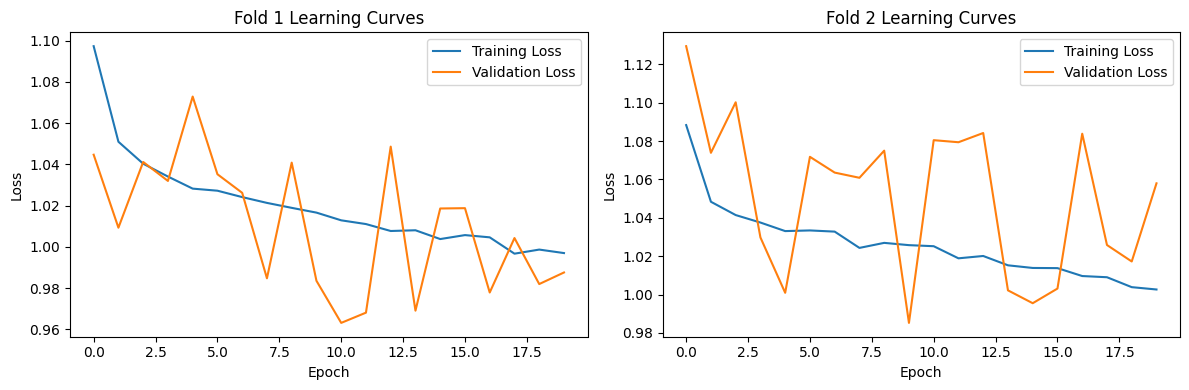

In [ ]:
## plot the training and validation loss curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fold_idx in [0, 1]:
    history = fold_histories[fold_idx]
    axes[fold_idx].plot(history.history['loss'], label='Training Loss')
    axes[fold_idx].plot(history.history['val_loss'], label='Validation Loss')
    axes[fold_idx].set_title(f'Fold {fold_idx + 1} Learning Curves')
    axes[fold_idx].set_xlabel('Epoch')
    axes[fold_idx].set_ylabel('Loss')
    axes[fold_idx].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'dnn_learning_curves.png', dpi=150)
plt.show()

In [ ]:
# one additional non-neural supervised learning model (random forest, xgboost, or decision tree)
## random forest
rf_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # preprocessing training data
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)


    model = RandomForestClassifier(n_estimators=100,
                               class_weight='balanced',
                               random_state=42,
                               n_jobs=-1)

    # fit model
    model.fit(X_train_proc, y_train)

    # predictions
    y_pred = model.predict(X_val_proc)

    # calculate metrics
    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
    }
    rf_results.append(results)
    print(f'Fold {fold + 1} done.')

print('RF complete.')

results_df = pd.DataFrame(rf_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1']].mean())

print('\nClassification Report (last fold):')
print(classification_report(y_val, y_pred,
      target_names=['Slight', 'Serious', 'Fatal'],
      zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))


Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.
RF complete.
   fold  accuracy  balanced_accuracy  macro_f1
0     1  0.750223           0.341068  0.307320
1     2  0.749331           0.339002  0.303440
2     3  0.748972           0.340696  0.307463
3     4  0.748724           0.339126  0.304223
4     5  0.749022           0.338527  0.302456

Mean scores:
accuracy             0.749254
balanced_accuracy    0.339684
macro_f1             0.304980
dtype: float64

Classification Report (last fold):
              precision    recall  f1-score   support

      Slight       0.75      0.99      0.86     15171
     Serious       0.40      0.03      0.05      4714
       Fatal       0.00      0.00      0.00       300

    accuracy                           0.75     20185
   macro avg       0.38      0.34      0.30     20185
weighted avg       0.66      0.75      0.66     20185

Confusion Matrix (last fold):
[[14989   182     0]
 [ 4584   130     0]
 [  286    14     0]]


In [ ]:
# compile mean results for all models
summary = pd.DataFrame({
    'Model': ['Majority Baseline', 'Logistic Regression', 'Random Forest', 'DNN'],
    'Accuracy': [
        pd.DataFrame(baseline_results)['accuracy'].mean(),
        pd.DataFrame(lr_results)['accuracy'].mean(),
        pd.DataFrame(rf_results)['accuracy'].mean(),
        pd.DataFrame(dnn_results)['accuracy'].mean(),
    ],
    'Balanced Accuracy': [
        pd.DataFrame(baseline_results)['balanced_accuracy'].mean(),
        pd.DataFrame(lr_results)['balanced_accuracy'].mean(),
        pd.DataFrame(rf_results)['balanced_accuracy'].mean(),
        pd.DataFrame(dnn_results)['balanced_accuracy'].mean(),
    ],
    'Macro F1': [
        pd.DataFrame(baseline_results)['macro_f1'].mean(),
        pd.DataFrame(lr_results)['macro_f1'].mean(),
        pd.DataFrame(rf_results)['macro_f1'].mean(),
        pd.DataFrame(dnn_results)['macro_f1'].mean(),
    ],
})

summary = summary.round(4)
print(summary.to_string(index=False))

              Model  Accuracy  Balanced Accuracy  Macro F1
  Majority Baseline    0.7516             0.3333    0.2861
Logistic Regression    0.4825             0.4747    0.3307
      Random Forest    0.7493             0.3397    0.3050
                DNN    0.5052             0.4715    0.3225


In [ ]:
# per-class metrics and confusion matrices for all models
models = {
    'Majority Baseline': (baseline_results, None),
    'Logistic Regression': (lr_results, None),
    'Random Forest': (rf_results, None),
    'DNN': (dnn_results, None),
}

# re-run last fold predictions for each model to get reports
print('=' * 60)

# baseline
model = DummyClassifier(strategy='most_frequent')
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
model.fit(X_train_proc, y_train)
y_pred_baseline = model.predict(X_val_proc)

print('MAJORITY BASELINE')
print(classification_report(y_val, y_pred_baseline,
      target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_baseline))
print('=' * 60)

# logistic regression
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_proc, y_train)
y_pred_lr = model.predict(X_val_proc)

print('LOGISTIC REGRESSION')
print(classification_report(y_val, y_pred_lr,
      target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_lr))
print('=' * 60)

# random forest
model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)
model.fit(X_train_proc, y_train)
y_pred_rf = model.predict(X_val_proc)

print('RANDOM FOREST')
print(classification_report(y_val, y_pred_rf,
      target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_rf))
print('=' * 60)

# DNN
model = build_model(X_train_proc.shape[1])
model.fit(X_train_proc, y_train, epochs=20, batch_size=256,
          class_weight=class_weight_dict, verbose=0)
y_pred_dnn = np.argmax(model.predict(X_val_proc), axis=1)

print('DNN')
print(classification_report(y_val, y_pred_dnn,
      target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_val, y_pred_dnn))
print('=' * 60)

MAJORITY BASELINE
              precision    recall  f1-score   support

      Slight       0.75      1.00      0.86     15171
     Serious       0.00      0.00      0.00      4714
       Fatal       0.00      0.00      0.00       300

    accuracy                           0.75     20185
   macro avg       0.25      0.33      0.29     20185
weighted avg       0.56      0.75      0.65     20185

Confusion Matrix:
[[15171     0     0]
 [ 4714     0     0]
 [  300     0     0]]
LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Slight       0.81      0.55      0.65     15171
     Serious       0.28      0.28      0.28      4714
       Fatal       0.04      0.62      0.07       300

    accuracy                           0.49     20185
   macro avg       0.38      0.48      0.34     20185
weighted avg       0.67      0.49      0.56     20185

Confusion Matrix:
[[8375 3291 3505]
 [1970 1329 1415]
 [  57   58  185]]
RANDOM FOREST
              precision    reca